# Two-Tower Shared-State Baseline

The previous experiments showed that the NLI model jointly encodes the
state and hypothesis, preventing straightforward reuse of the final state
representation.

This experiment tests a simpler two-tower architecture:

1. Encode the state once.
2. Encode all questions independently in a batch.
3. Compare the state embedding with each question embedding.
4. Use similarity as a first approximation of decision relevance.

No training or calibration is performed at this stage.

In [1]:
from sentence_transformers import SentenceTransformer

In [2]:
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device="cuda",
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
state = """
Inspect the repository, identify which commit introduced the login bug,
run the relevant tests, and explain the likely cause.
"""

In [4]:
hypotheses = [
    "This task requires filesystem access.",
    "This task requires Git access.",
    "This task requires shell execution.",
    "This task requires browser access.",
    "This task requires email access.",
    "This task requires calendar access.",
]

In [5]:
state_embedding = model.encode(
    state,
    convert_to_tensor=True,
)

In [6]:
question_embeddings = model.encode(
    hypotheses,
    convert_to_tensor=True,
)

In [7]:
print("State:", state_embedding.shape)
print("Questions:", question_embeddings.shape)

State: torch.Size([384])
Questions: torch.Size([6, 384])


In [8]:
from sentence_transformers import util

In [9]:
similarities = util.cos_sim(
    state_embedding,
    question_embeddings,
)[0]

similarities

tensor([0.0845, 0.2250, 0.0401, 0.0948, 0.1094, 0.0633], device='cuda:0')

In [10]:
for hypothesis, score in zip(hypotheses, similarities):
    print(f"{score.item():.4f}  {hypothesis}")

0.0845  This task requires filesystem access.
0.2250  This task requires Git access.
0.0401  This task requires shell execution.
0.0948  This task requires browser access.
0.1094  This task requires email access.
0.0633  This task requires calendar access.


## Similarity Scores

The two-tower model produces cosine similarity scores between the shared
state embedding and each question embedding.

These scores are **not calibrated probabilities**. They only measure
semantic similarity in the embedding space.

For now, this experiment tests whether independently encoded questions
can still capture useful routing signals while allowing the state to be
encoded only once.

## Comparison with the NLI Baseline

The two-tower model provides genuine shared-state encoding, but cosine
similarity alone may not be sufficient for decision routing.

Next, we compare its scores with the existing NLI backend using the same
state and hypotheses.

In [11]:
from parallel_decider import BooleanQuestion, NLIBackend

nli_backend = NLIBackend()

/home/mebus/workspace/parallel-decider/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [12]:
questions = [
    BooleanQuestion(
        name=f"q_{index}",
        hypothesis=hypothesis,
    )
    for index, hypothesis in enumerate(hypotheses)
]

In [13]:
nli_results = nli_backend.decide(
    state=state,
    questions=questions,
)

In [14]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "hypothesis": hypotheses,
        "two_tower_similarity": [
            score.item()
            for score in similarities
        ],
        "nli_probability": [
            result.probability
            for result in nli_results
        ],
    }
)

comparison

,hypothesis,two_tower_similarity,nli_probability
0,This task requires filesystem access.,0.084494,0.929199
1,This task requires Git access.,0.225041,0.921387
2,This task requires shell execution.,0.040054,0.070129
3,This task requires browser access.,0.094790,0.019150
4,This task requires email access.,0.109350,0.001127
5,This task requires calendar access.,0.063290,0.000121


In [15]:
comparison.sort_values(
    "nli_probability",
    ascending=False,
)

,hypothesis,two_tower_similarity,nli_probability
0,This task requires filesystem access.,0.084494,0.929199
1,This task requires Git access.,0.225041,0.921387
2,This task requires shell execution.,0.040054,0.070129
3,This task requires browser access.,0.094790,0.019150
4,This task requires email access.,0.109350,0.001127
5,This task requires calendar access.,0.063290,0.000121


## Asymmetric Two-Tower Baseline

The first two-tower experiment used a general semantic-similarity model.
While it successfully identified Git as relevant, its ranking of the other
capabilities was poor compared with the NLI baseline.

Next, we test an asymmetric retrieval model. The user task is encoded as a
query, while each routing hypothesis is encoded as a candidate passage.

This still preserves the main architectural property we are interested in:
the state is encoded only once.

In [16]:
from sentence_transformers import SentenceTransformer, util

e5_model = SentenceTransformer(
    "intfloat/e5-small-v2",
    device="cuda",
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [17]:
query = f"query: {state}"

passages = [
    f"passage: {hypothesis}"
    for hypothesis in hypotheses
]

In [18]:
e5_state_embedding = e5_model.encode(
    query,
    convert_to_tensor=True,
    normalize_embeddings=True,
)

e5_question_embeddings = e5_model.encode(
    passages,
    convert_to_tensor=True,
    normalize_embeddings=True,
)

In [19]:
e5_similarities = util.cos_sim(
    e5_state_embedding,
    e5_question_embeddings,
)[0]

In [20]:
for hypothesis, score in zip(
    hypotheses,
    e5_similarities,
):
    print(
        f"{score.item():.4f}  "
        f"{hypothesis}"
    )

0.7870  This task requires filesystem access.
0.7977  This task requires Git access.
0.7938  This task requires shell execution.
0.8075  This task requires browser access.
0.7843  This task requires email access.
0.7749  This task requires calendar access.


In [21]:
comparison["e5_similarity"] = [
    score.item()
    for score in e5_similarities
]

comparison

,hypothesis,two_tower_similarity,nli_probability,e5_similarity
0,This task requires filesystem access.,0.084494,0.929199,0.786985
1,This task requires Git access.,0.225041,0.921387,0.797686
2,This task requires shell execution.,0.040054,0.070129,0.793829
3,This task requires browser access.,0.094790,0.019150,0.807467
4,This task requires email access.,0.109350,0.001127,0.784279
5,This task requires calendar access.,0.063290,0.000121,0.774895


## Observation

The asymmetric E5 retrieval model does not improve the decision signal.

All routing hypotheses receive similarly high cosine-similarity scores,
including clearly irrelevant capabilities such as browser, email, and calendar.

This suggests that retrieval-style semantic similarity is not sufficient for
our task. The desired behavior is closer to natural-language inference:
given a state and a proposition, determine whether the proposition is supported
by the state.

The shared-state architecture therefore likely needs a learned decision scorer,
not raw embedding similarity.

In [22]:
from parallel_decider.two_tower import TwoTowerDecisionHead
import torch

head = TwoTowerDecisionHead(
    embedding_dim=384,
    hidden_dim=256,
).to("cuda")

In [23]:
logits = head(
    state_embedding,
    question_embeddings,
)

probabilities = torch.sigmoid(logits)

probabilities

tensor([0.5112, 0.5131, 0.5128, 0.5101, 0.5128, 0.5111], device='cuda:0',
       grad_fn=<SigmoidBackward0>)

In [24]:
for hypothesis, probability in zip(
    hypotheses,
    probabilities,
):
    print(
        f"{probability.item():.4f}  "
        f"{hypothesis}"
    )

0.5112  This task requires filesystem access.
0.5131  This task requires Git access.
0.5128  This task requires shell execution.
0.5101  This task requires browser access.
0.5128  This task requires email access.
0.5111  This task requires calendar access.


## Preparing Training Inputs

Before training the decision head, we convert one labeled routing example into:

- one state embedding,
- one embedding per routing question,
- one binary target per question.

This verifies that the dataset and model shapes line up correctly.

In [25]:
from parallel_decider.dataset import ROUTING_LABELS, load_routing_dataset

examples = load_routing_dataset("../data/routing_v0.jsonl")
example = examples[0]

example

RoutingExample(state='Find which commit introduced the authentication bug.', labels={'needs_filesystem': 1, 'needs_git': 1, 'needs_shell': 0, 'needs_browser': 0, 'needs_network': 0, 'needs_database': 0, 'needs_email': 0, 'needs_calendar': 0})

In [26]:
routing_hypotheses = {
    "needs_filesystem": "This task requires filesystem access.",
    "needs_git": "This task requires Git access.",
    "needs_shell": "This task requires shell execution.",
    "needs_browser": "This task requires browser access.",
    "needs_network": "This task requires network access.",
    "needs_database": "This task requires database access.",
    "needs_email": "This task requires email access.",
    "needs_calendar": "This task requires calendar access.",
}

In [27]:
state_embedding = model.encode(
    example.state,
    convert_to_tensor=True,
)

question_embeddings = model.encode(
    [
        routing_hypotheses[label]
        for label in ROUTING_LABELS
    ],
    convert_to_tensor=True,
)

In [28]:
import torch

targets = torch.tensor(
    [
        example.labels[label]
        for label in ROUTING_LABELS
    ],
    dtype=torch.float32,
    device=state_embedding.device,
)

In [29]:
print("State:", state_embedding.shape)
print("Questions:", question_embeddings.shape)
print("Targets:", targets.shape)
print("Targets:", targets)

State: torch.Size([384])
Questions: torch.Size([8, 384])
Targets: torch.Size([8])
Targets: tensor([1., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0')


## First Training Step

The shared-state decision head is currently untrained, so its outputs are expected to stay close to random probabilities around `0.5`.

In this step, we perform a single optimization update on one labeled routing example.

The goal is not to achieve useful accuracy yet. Instead, we verify that the full training path works correctly:

1. Encode the state once.
2. Encode all routing questions in a batch.
3. Produce one logit per decision.
4. Compare the logits with the binary targets.
5. Compute the loss.
6. Backpropagate through the decision head.
7. Update the head parameters.

If the pipeline is wired correctly, the loss after the optimization step should be lower than the loss before the step.

The sentence encoder remains frozen during this experiment. Only the lightweight `TwoTowerDecisionHead` is trained.

In [30]:
import torch.nn as nn

head = TwoTowerDecisionHead(
    embedding_dim=384,
    hidden_dim=256,
).to("cuda")

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    head.parameters(),
    lr=1e-3,
)

In [31]:
logits = head(
    state_embedding=state_embedding,
    question_embeddings=question_embeddings,
)

loss = criterion(
    logits,
    targets,
)

print("Loss before step:", loss.item())

Loss before step: 0.6989326477050781


In [32]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

In [33]:
with torch.no_grad():
    new_logits = head(
        state_embedding=state_embedding,
        question_embeddings=question_embeddings,
    )

    new_loss = criterion(
        new_logits,
        targets,
    )

print("Loss after step:", new_loss.item())

Loss after step: 0.6544320583343506


In [34]:
probabilities = torch.sigmoid(new_logits)

for label, probability, target in zip(
    ROUTING_LABELS,
    probabilities,
    targets,
):
    print(
        f"{label:<20} "
        f"p={probability.item():.4f} "
        f"target={int(target.item())}"
    )

needs_filesystem     p=0.4648 target=1
needs_git            p=0.4660 target=1
needs_shell          p=0.4631 target=0
needs_browser        p=0.4608 target=0
needs_network        p=0.4608 target=0
needs_database       p=0.4609 target=0
needs_email          p=0.4592 target=0
needs_calendar       p=0.4599 target=0


## Observation

The loss decreased after a single optimization step, confirming that the
decision head is receiving gradients and updating correctly.

The individual probabilities remain close to `0.5`, which is expected after
only one training step on one example.

At this stage, the experiment verifies the training pipeline rather than model
quality.

## Overfitting the Tiny Routing Dataset

Now that a single optimization step works, we train the decision head on all
10 labeled examples.

This is intentionally **not** a realistic training setup. The dataset is far
too small for generalization.

The goal is a sanity check:

> Can the lightweight decision head learn this tiny dataset at all?

A healthy model should be able to drive the training loss down significantly
and reproduce the labels on these examples. If it cannot, we likely have a
problem in the architecture, data preparation, or optimization loop.

In [35]:
head = TwoTowerDecisionHead(
    embedding_dim=384,
    hidden_dim=256,
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    head.parameters(),
    lr=1e-3,
)

In [36]:
question_embeddings = model.encode(
    [
        routing_hypotheses[label]
        for label in ROUTING_LABELS
    ],
    convert_to_tensor=True,
)

In [37]:
training_data = []

for example in examples:
    state_embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    )

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=state_embedding.device,
    )

    training_data.append(
        (state_embedding, targets)
    )

In [38]:
from tqdm.auto import tqdm

epochs = 100

loss_history = []

progress = tqdm(
    range(epochs),
    desc="Training",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in training_data:
        optimizer.zero_grad()

        logits = head(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(training_data)
    loss_history.append(average_loss)

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training:   0%|          | 0/100 [00:00<?, ?it/s]

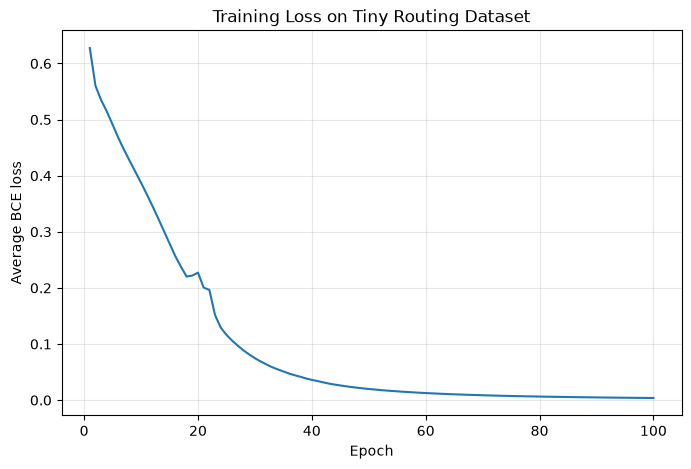

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
)

plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("Training Loss on Tiny Routing Dataset")
plt.grid(True, alpha=0.3)

plt.show()

## Training-Set Evaluation

The decision head successfully drove the training loss close to zero on the
tiny dataset.

Next, we inspect the actual predictions for every training example.

This is still an overfitting test, not a measure of generalization. The goal is
to verify that low loss corresponds to the expected routing decisions.

In [40]:
head.eval()

with torch.no_grad():
    for index, (example, (state_embedding, targets)) in enumerate(
        zip(examples, training_data),
        start=1,
    ):
        logits = head(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        print(f"\nExample {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Example 1
Find which commit introduced the authentication bug.
needs_filesystem     p=0.997 pred=1 target=1
needs_git            p=0.989 pred=1 target=1
needs_shell          p=0.005 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.008 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Example 2
Run the test suite and show me which tests are failing.
needs_filesystem     p=0.994 pred=1 target=1
needs_git            p=0.003 pred=0 target=0
needs_shell          p=0.995 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.006 pred=0 target=0
needs_database       p=0.001 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Example 3
Open the project files and explain how authentication is implemented.
needs_filesystem     p=0.995 pred=1 target=1
needs_git            p=

## Observation

The trained decision head reproduces the labels of the 10-example training set with very high confidence.

This confirms that:

- the state and question embeddings contain enough information for the routing task,
- the interaction features are usable,
- the decision head has sufficient capacity,
- and the training pipeline is functioning correctly.

However, this result does **not** demonstrate generalization. The model was evaluated on the same examples it was trained on.

The next step is therefore to test the model on unseen requests.

In [41]:
test_cases = [
    {
        "state": "Look through the source code and tell me where user sessions are created.",
        "labels": {
            "needs_filesystem": 1,
            "needs_git": 0,
            "needs_shell": 0,
            "needs_browser": 0,
            "needs_network": 0,
            "needs_database": 0,
            "needs_email": 0,
            "needs_calendar": 0,
        },
    },
    {
        "state": "Find the commit that removed the password validation check.",
        "labels": {
            "needs_filesystem": 1,
            "needs_git": 1,
            "needs_shell": 0,
            "needs_browser": 0,
            "needs_network": 0,
            "needs_database": 0,
            "needs_email": 0,
            "needs_calendar": 0,
        },
    },
    {
        "state": "Search online for the current Rust release and summarize the changes.",
        "labels": {
            "needs_filesystem": 0,
            "needs_git": 0,
            "needs_shell": 0,
            "needs_browser": 1,
            "needs_network": 1,
            "needs_database": 0,
            "needs_email": 0,
            "needs_calendar": 0,
        },
    },
    {
        "state": "Show me the appointments on my calendar for Friday.",
        "labels": {
            "needs_filesystem": 0,
            "needs_git": 0,
            "needs_shell": 0,
            "needs_browser": 0,
            "needs_network": 1,
            "needs_database": 0,
            "needs_email": 0,
            "needs_calendar": 1,
        },
    },
    {
        "state": "Find the message where Alice sent me the deployment credentials.",
        "labels": {
            "needs_filesystem": 0,
            "needs_git": 0,
            "needs_shell": 0,
            "needs_browser": 0,
            "needs_network": 1,
            "needs_database": 0,
            "needs_email": 1,
            "needs_calendar": 0,
        },
    },
]

In [42]:
head.eval()

with torch.no_grad():
    for index, case in enumerate(test_cases, start=1):
        state_embedding = model.encode(
            case["state"],
            convert_to_tensor=True,
        )

        logits = head(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        probabilities = torch.sigmoid(logits)

        print(f"\nTest {index}")
        print(case["state"])

        for label, probability in zip(
            ROUTING_LABELS,
            probabilities,
        ):
            target = case["labels"][label]
            prediction = int(probability.item() >= 0.5)

            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={prediction} "
                f"target={target}"
            )


Test 1
Look through the source code and tell me where user sessions are created.
needs_filesystem     p=0.462 pred=0 target=1
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.003 pred=0 target=0
needs_browser        p=0.010 pred=0 target=0
needs_network        p=0.071 pred=0 target=0
needs_database       p=0.002 pred=0 target=0
needs_email          p=0.001 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Find the commit that removed the password validation check.
needs_filesystem     p=0.996 pred=1 target=1
needs_git            p=0.115 pred=0 target=1
needs_shell          p=0.044 pred=0 target=0
needs_browser        p=0.003 pred=0 target=0
needs_network        p=0.052 pred=0 target=0
needs_database       p=0.002 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Search online for the current Rust release and summarize the changes.
needs_filesystem     p=0.351 pred=0 target=0
needs_g

## Generalization Result

The model successfully memorized the tiny training dataset, but performance on unseen requests is poor.

Some concepts transfer partially, such as calendar access, but several routing decisions fail even when the unseen request is semantically similar to a training example.

Examples include:

- missing Git access for a commit-related request,
- missing browser and network access for an online search,
- missing email access for a message-search request,
- incorrectly predicting filesystem access for an email-related request.

This confirms that the current 10-example dataset is sufficient for validating the training pipeline, but far too small to learn robust routing behavior.

The next step is to expand the labeled dataset before changing the model architecture.

## Train/Test Split

The V1 dataset contains 50 hand-labeled routing examples.

To measure generalization, we split the dataset into separate training and test sets. The split uses a fixed random seed so benchmark results remain reproducible across runs.

In [44]:
import random

examples = load_routing_dataset("../data/routing_v1.jsonl")

rng = random.Random(42)

shuffled_examples = examples.copy()
rng.shuffle(shuffled_examples)

split_index = int(len(shuffled_examples) * 0.8)

train_examples = shuffled_examples[:split_index]
test_examples = shuffled_examples[split_index:]

print("Training examples:", len(train_examples))
print("Test examples:", len(test_examples))

Training examples: 40
Test examples: 10


In [45]:
def label_counts(examples):
    counts = {
        label: 0
        for label in ROUTING_LABELS
    }

    for example in examples:
        for label in ROUTING_LABELS:
            counts[label] += example.labels[label]

    return counts

In [46]:
train_counts = label_counts(train_examples)
test_counts = label_counts(test_examples)

for label in ROUTING_LABELS:
    print(
        f"{label:<20} "
        f"train={train_counts[label]:>2} "
        f"test={test_counts[label]:>2}"
    )

needs_filesystem     train=20 test= 4
needs_git            train= 7 test= 2
needs_shell          train= 6 test= 2
needs_browser        train= 8 test= 1
needs_network        train=15 test= 4
needs_database       train= 5 test= 2
needs_email          train= 4 test= 2
needs_calendar       train= 3 test= 2


### Label Distribution

The dataset is still small, so some routing capabilities have only a few
positive examples in the test split.

This means per-capability metrics should be interpreted cautiously. The goal
of this V1 experiment is not to establish production-quality accuracy, but to
measure whether a larger and more varied training set improves generalization
over the initial 10-example prototype.

In [47]:
question_embeddings = model.encode(
    [
        routing_hypotheses[label]
        for label in ROUTING_LABELS
    ],
    convert_to_tensor=True,
)

In [48]:
train_data = []

for example in train_examples:
    state_embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    )

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=state_embedding.device,
    )

    train_data.append(
        (state_embedding, targets)
    )

In [49]:
print("Training samples:", len(train_data))
print("State shape:", train_data[0][0].shape)
print("Target shape:", train_data[0][1].shape)

Training samples: 40
State shape: torch.Size([384])
Target shape: torch.Size([8])


## V1 Training

We now train a fresh `TwoTowerDecisionHead` using only the 40-example training split.

The sentence encoder remains frozen. Only the lightweight decision head is optimized.

The 10 held-out test examples are not used during training.

In [50]:
head_v1 = TwoTowerDecisionHead(
    embedding_dim=384,
    hidden_dim=256,
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    head_v1.parameters(),
    lr=1e-3,
)

In [51]:
epochs = 100
loss_history_v1 = []

progress = tqdm(
    range(epochs),
    desc="Training V1",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in train_data:
        optimizer.zero_grad()

        logits = head_v1(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data)
    loss_history_v1.append(average_loss)

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training V1:   0%|          | 0/100 [00:00<?, ?it/s]

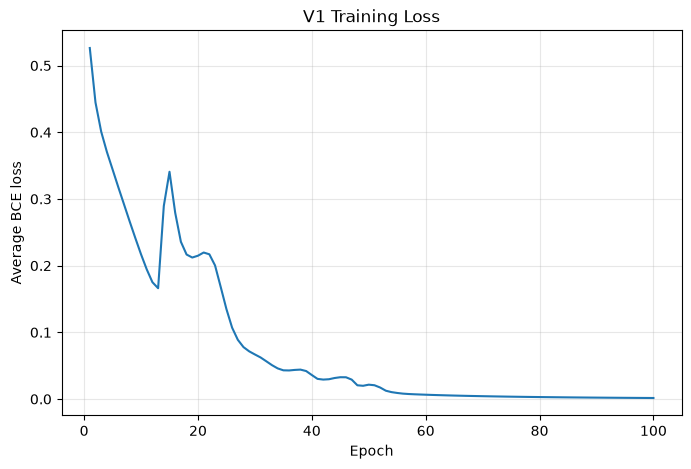

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history_v1,
)

plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("V1 Training Loss")
plt.grid(True, alpha=0.3)

plt.show()

## V1 Held-Out Evaluation

The model achieved very low loss on the 40-example training split.

We now evaluate it on the 10 examples that were never used during training.

This is the first meaningful test of whether the shared-state decision head has learned routing behavior that transfers beyond memorized examples.

In [53]:
test_data = []

for example in test_examples:
    state_embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    )

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=state_embedding.device,
    )

    test_data.append(
        (example, state_embedding, targets)
    )

In [54]:
head_v1.eval()

total_correct = 0
total_decisions = 0

with torch.no_grad():
    for index, (
        example,
        state_embedding,
        targets,
    ) in enumerate(test_data, start=1):

        logits = head_v1(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_correct += (
            predictions == targets
        ).sum().item()

        total_decisions += len(targets)

        print(f"\nTest {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Test 1
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.002 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.234 pred=0 target=0
needs_network        p=0.996 pred=1 target=1
needs_database       p=0.003 pred=0 target=0
needs_email          p=0.488 pred=0 target=0
needs_calendar       p=0.807 pred=1 target=1

Test 2
Find the conversation where the recruiter confirmed the interview time.
needs_filesystem     p=0.002 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.002 pred=0 target=0
needs_network        p=0.970 pred=1 target=1
needs_database       p=0.165 pred=0 target=0
needs_email          p=0.951 pred=1 target=1
needs_calendar       p=0.000 pred=0 target=0

Test 3
Find all customers whose subscription expired yesterday.
needs_filesystem     p=0.953 pred=1 target=0
needs_git            p=0.001 

In [55]:
accuracy = total_correct / total_decisions

print(
    f"\nOverall decision accuracy: "
    f"{accuracy:.3%}"
)


Overall decision accuracy: 90.000%


## Per-Capability Evaluation

Overall accuracy can be misleading for this task because most routing labels
are negative.

A model that predicts `false` for every capability could still achieve a high
accuracy on an imbalanced dataset.

We therefore evaluate each routing capability separately using:

- **Precision** — when the model selects a capability, how often is it correct?
- **Recall** — when a capability is actually required, how often does the model detect it?
- **F1 score** — the harmonic mean of precision and recall.

For agent routing, recall is particularly important because omitting a required
tool can prevent the agent from completing the task.

In [56]:
all_targets = []
all_predictions = []

head_v1.eval()

with torch.no_grad():
    for example, state_embedding, targets in test_data:
        logits = head_v1(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).int()

        all_targets.append(targets.int().cpu())
        all_predictions.append(predictions.cpu())

all_targets = torch.stack(all_targets)
all_predictions = torch.stack(all_predictions)

print(all_targets.shape)
print(all_predictions.shape)

torch.Size([10, 8])
torch.Size([10, 8])


In [57]:
metrics = []

for index, label in enumerate(ROUTING_LABELS):
    targets = all_targets[:, index]
    predictions = all_predictions[:, index]

    tp = ((predictions == 1) & (targets == 1)).sum().item()
    fp = ((predictions == 1) & (targets == 0)).sum().item()
    fn = ((predictions == 0) & (targets == 1)).sum().item()
    tn = ((predictions == 0) & (targets == 0)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0.0
    )

    metrics.append(
        {
            "label": label,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )

In [58]:
import pandas as pd
metrics_df = pd.DataFrame(metrics)

metrics_df[
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,0.75,0.75,0.750,3,1,1
1,needs_git,1.00,0.50,0.667,1,0,1
2,needs_shell,1.00,1.00,1.000,2,0,0
3,needs_browser,0.00,0.00,0.000,0,0,1
4,needs_network,0.75,0.75,0.750,3,1,1
5,needs_database,1.00,0.50,0.667,1,0,1
6,needs_email,1.00,1.00,1.000,2,0,0
7,needs_calendar,1.00,0.50,0.667,1,0,1


## Observation

The per-capability metrics reveal substantial variation that is hidden by
the overall accuracy score.

Strong capabilities:

- `needs_shell`: precision 1.00, recall 1.00
- `needs_email`: precision 1.00, recall 1.00

Moderate capabilities:

- `needs_filesystem`: F1 0.75
- `needs_network`: F1 0.75
- `needs_git`: high precision but only 0.50 recall
- `needs_database`: high precision but only 0.50 recall
- `needs_calendar`: high precision but only 0.50 recall

Weak capability:

- `needs_browser`: recall 0.00 on the held-out split

The test set is still very small, so these values should not be interpreted
as stable performance estimates. However, they are useful for identifying
where additional training examples are needed.